# LeadLens — walkthrough notebook

**What this shows:** a raw, messy scraped lead list (the kind SaaSquatch / Apollo / a Google-Maps scrape produces) going through
`dedupe → validate → enrich → score`, and coming out as a ranked shortlist where every score has a plain-English rationale.

Run top-to-bottom. Cells 1–5 are fully offline (synthetic `.test` domains). Cell 6 optionally hits real websites.

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "..")
import pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 40)

from leadlens.pipeline import run_pipeline, map_columns
from leadlens.export import to_dataframe, to_csv_bytes
from leadlens.storage import Cache

raw = pd.read_csv("../data/sample_leads.csv")
print(raw.shape)
raw.head(8)

(82, 14)


,Company Name,Website,Industry,City,State,Country,Employees,Est. Revenue,Owner,Title,Email,Phone,LinkedIn,Source
0,Copper Crypto Inc.,NaN,Crypto Exchange,Calgary,Alberta,Canada,NaN,11472328,NaN,NaN,tomschmidt@@copper-crypto.test,919-555-0158,NaN,linkedin_scrape
1,Copper Crypto LLC,NaN,Crypto Exchange,Phoenix,Arizona,United States,25+,NaN,Aisha Silva,Managing Partner,info@copper-crypto.test,NaN,NaN,google_maps
2,Evergreen Landscapes,http://evergreen-landscapes.test,Landscaping,Austin,Texas,United States,17+,"$1,756,514",Sam Ross,Founder,info@evergreen-landscapes.test,NaN,https://www.linkedin.com/company/eve...,google_maps
3,FALCON KITCHEN,NaN,Restaurant,Denver,Colorado,USA,NaN,NaN,NaN,Owner,priyabrooks@@falcon-kitchen.test,NaN,NaN,linkedin_scrape
4,Granite IT Solutions,www.granite-it.test/about-us,Managed IT Services,Sydney,NSW,Australia,NaN,NaN,Nina Nguyen,Founder,ninanguyen@@granite-it.test,480.555.0184,NaN,manual
5,Atlas Boutique,atlas-boutique.test,Retail Boutique,Boise,Idaho,USA,6+,"1,025,654",NaN,Owner,mfischer@atlas-boutique.test,(212) 555-0126,https://www.linkedin.com/company/atl...,saasquatch
6,Evergreen Realty LLC,evergreen-realty.test,Real Estate,Boise,Idaho,UNITED STATES,307+,"38,697,496",Yuki Schmidt,NaN,info@evergreen-realty.test,(614) 555-0135,NaN,yelp
7,BLUE RIDGE LANDSCAPES INC,https://blue-ridge-landscapes.test,Landscaping,Manchester,NaN,UNITED KINGDOM,10-50,NaN,Sam Patel,NaN,NaN,NaN,NaN,linkedin_scrape


## 1. The input is messy on purpose
Look at the raw rows: inconsistent URLs (`www.`, trailing paths, bare domains), revenue as `$1.7M` / `3.30M` / `3,963,033`,
headcount as ranges, phone numbers in five formats, broken emails (`@@`), and the same company appearing twice under slightly different names.
That's what real scrapes look like, and it's why a plain export isn't actionable.

In [2]:
print("Recognised columns:", map_columns(raw))
dupes = raw[raw["Company Name"].str.upper().str.replace(r"[^A-Z ]", "", regex=True).duplicated(keep=False)].sort_values("Company Name")
dupes[["Company Name", "Website", "Email", "Phone", "Source"]].head(10)

Recognised columns: {'company': 'Company Name', 'website': 'Website', 'industry': 'Industry', 'city': 'City', 'state': 'State', 'country': 'Country', 'employees': 'Employees', 'revenue': 'Est. Revenue', 'owner_name': 'Owner', 'owner_title': 'Title', 'email': 'Email', 'phone': 'Phone', 'linkedin': 'LinkedIn', 'source': 'Source'}


,Company Name,Website,Email,Phone,Source
48,ATLAS BOUTIQUE,https://atlas-boutique.test,NaN,NaN,linkedin_scrape
31,"Atlas Animal Hospital, Inc.",atlas-animal.test/,NaN,(208) 555-0164,yelp
27,"Atlas Animal Hospital, Inc.",atlas-animal.test/,yuki.kowalski@gmail.com,+1 615 555 0116,manual
5,Atlas Boutique,atlas-boutique.test,mfischer@atlas-boutique.test,(212) 555-0126,saasquatch
7,BLUE RIDGE LANDSCAPES INC,https://blue-ridge-landscapes.test,NaN,NaN,linkedin_scrape
14,Blue Ridge Landscapes Inc,http://blue-ridge-landscapes.test,spatel@blue-ridge-landscapes.test,+1 720 555 0141,yelp
29,CEDAR LANDSCAPES,https://cedar-landscapes.test,gchen@cedar-landscapes.test,(480) 555-0124,linkedin_scrape
23,Cedar Landscapes,cedar-landscapes.test/,gchen@cedar-landscapes.test,(480) 555-0124,yelp
41,IRONCLAD PLUMBING,https://ironclad-plumbing.test,NaN,NaN,linkedin_scrape
25,Ironclad Plumbing,https://www.ironclad-plumbing.test,info@ironclad-plumbing.test,615.555.0147,yelp


## 2. Run the pipeline (offline: no enrichment, no DNS)

In [3]:
res = run_pipeline(raw, cache=Cache(":memory:"), enrich=False, check_mx=False)
print(f"{res.rows_in} rows -> {res.rows_after_dedupe} unique ({res.duplicates_removed} duplicates merged) in {res.elapsed_s}s")
print("Tiers:", res.tier_counts)
table = to_dataframe(res.scored)
table[["fit_score", "tier", "company", "industry", "country", "employees", "revenue", "email", "phone_e164", "merged_from", "flags"]].head(12)

82 rows -> 63 unique (19 duplicates merged) in 0.09s
Tiers: {'Hot': 22, 'Warm': 37, 'Cold': 4}


,fit_score,tier,company,industry,country,employees,revenue,email,phone_e164,merged_from,flags
0,88.0,Hot,Evergreen Electric,Electrical Contractor,USA,30.0,3400000.0,oschmidt@evergreen-electric.test,+17205550130,1,
1,86.8,Hot,Ironclad Software LLC,B2B SaaS,UNITED STATES,30.0,2625866.0,omar.hassan@gmail.com,+18135550103,2,merged-2
2,86.8,Hot,"Atlas Animal Hospital, Inc.",Veterinary Clinic,United States,40.0,4600792.0,yuki.kowalski@gmail.com,+16155550116,2,merged-2
3,86.0,Hot,Cedar Electric,Electrical Contractor,UNITED STATES,20.0,NaN,nalvarez@cedar-electric.test,+12125550149,1,
4,85.5,Hot,Granite Animal Hospital Inc,Veterinary Clinic,United States,60.0,13100417.0,lschmidt@granite-animal.test,+12085550138,1,
5,85.5,Hot,Beacon Animal Hospital Inc,Veterinary Clinic,United States,30.0,1374281.0,tbrooks@beacon-animal.test,+17205550189,1,
6,85.3,Hot,Ironclad Landscapes,Landscaping,UNITED STATES,203.0,NaN,info@ironclad-landscapes.test,+13055550150,1,
7,84.0,Hot,Ironclad Plumbing,Plumbing,UNITED STATES,8.0,1100000.0,info@ironclad-plumbing.test,+16155550147,2,merged-2
8,83.2,Hot,"Cedar CPA Group, Inc.",Accounting Firm,UNITED STATES,NaN,9111240.0,info@cedar-cpa.test,+16155550196,1,
9,82.2,Hot,Keystone CPA Group,Accounting Firm,UNITED STATES,130.0,NaN,info@keystone-cpa.test,+16155550118,2,merged-2


## 3. Every score is explainable
No ML black box: six weighted components (weights live in `config/icp.yaml`), each with a reason a sales rep can read.

In [4]:
top = res.scored[0]
print(f"{top.lead.company} — {top.tier} {top.fit_score}/100\n")
for b in sorted(top.breakdown, key=lambda b: -b.points):
    print(f"  {b.points:5.1f} / {b.weight:<3.0f}  {b.component:<18} {b.reason}")

Evergreen Electric — Hot 88.0/100

   25.0 / 25   industry_fit       Target industry match ('electrical')
   20.0 / 20   size_fit           Headcount 30 inside target band; revenue $3.4m inside target band
   20.0 / 25   contact_quality    email syntax ok, MX unverified, valid phone, owner/decision-maker named, LinkedIn present
   10.0 / 10   geography_fit      In target geography (USA)
   10.0 / 10   data_completeness  10/10 key fields present
    3.0 / 10   web_presence       Website not enriched


In [5]:
# ...and the bottom of the list, so you can see what the tool is filtering OUT
bottom = res.scored[-1]
print(f"{bottom.lead.company} — {bottom.tier} {bottom.fit_score}/100\n")
for b in sorted(bottom.breakdown, key=lambda b: -b.points):
    print(f"  {b.points:5.1f} / {b.weight:<3.0f}  {b.component:<18} {b.reason}")

Meridian Crypto — Cold 38.6/100

   19.4 / 20   size_fit           Headcount 10 inside target band; revenue $1.0m below target band
   11.2 / 25   contact_quality    no email, valid phone, owner/decision-maker named
    8.0 / 10   data_completeness  8/10 key fields present
    0.0 / 25   industry_fit       Excluded industry ('crypto')
    0.0 / 10   geography_fit      Country 'Australia' outside target geography
    0.0 / 10   web_presence       No website


## 4. Score distribution & data-quality flags

Matplotlib is building the font cache; this may take a moment.


flags
merged-2     12
no-email     11
bad-email     3
merged-3      2
merged-4      1
Name: count, dtype: int64

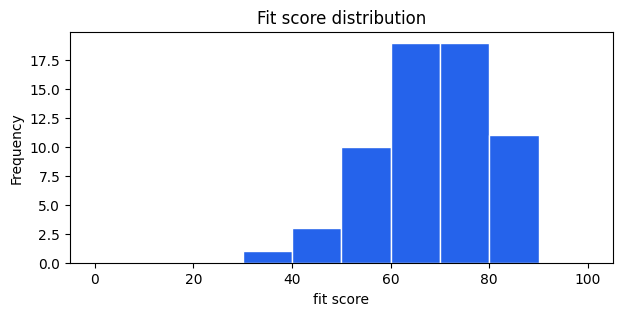

In [6]:
ax = table["fit_score"].plot.hist(bins=range(0, 101, 10), color="#2563eb", edgecolor="white", figsize=(7, 3), title="Fit score distribution")
ax.set_xlabel("fit score")
flags = table["flags"].str.split(", ").explode().replace("", pd.NA).dropna().value_counts()
flags

## 5. Export straight into a CRM
`to_csv_bytes(..., crm=True)` renames columns to HubSpot's importer names and puts the rationale into *Notes*.

In [7]:
crm = to_csv_bytes(table[table["tier"] == "Hot"], crm=True).decode()
print(crm.splitlines()[0])
print(crm.splitlines()[1][:200], "...")

Company name,Company domain name,Industry,City,State/Region,Country/Region,Number of Employees,Annual Revenue,Contact name,Job Title,Email,Phone Number,LinkedIn URL,Website URL,Lead Score,Lead Status,Notes
Evergreen Electric,evergreen-electric.test,Electrical Contractor,Austin,Texas,USA,30.0,3400000.0,Omar Schmidt,General Manager,oschmidt@evergreen-electric.test,+17205550130,https://www.linkedin.com/com ...


## 6. (Optional, needs internet) Live enrichment on real company sites
Respects `robots.txt`, identifies itself, 1 request/second/host, results cached in SQLite for 7 days — so the second run is instant.

In [8]:
live = pd.read_csv("../data/sample_leads_live.csv")
cache = Cache(":memory:")
r1 = run_pipeline(live, cache=cache, enrich=True, check_mx=True)
r2 = run_pipeline(live, cache=cache, enrich=True, check_mx=True)
print(f"first run {r1.elapsed_s}s (stages {r1.stage_times}) -> cached run {r2.elapsed_s}s, {r2.cache_hits} cache hits")
to_dataframe(r1.scored)[["fit_score", "tier", "company", "site_live", "site_title", "email", "email_verified", "socials", "tech", "hiring"]]

first run 4.8s (stages {'parse': 0.01, 'dedupe': 0.0, 'validate': 0.0, 'enrich': 4.7, 'score': 0.1}) -> cached run 0.04s, 8 cache hits


,fit_score,tier,company,site_live,site_title,email,email_verified,socials,tech,hiring
0,81.2,Hot,Basecamp,True,Basecamp,jason@basecamp.com,True,,,False
1,77.1,Hot,ConvertKit,True,Kit: The Platform for Creators - Ema...,help@kit.com,True,"youtube, twitter, facebook, instagra...",Next.js,True
2,71.0,Warm,Buffer,True,Buffer: Social media management for ...,None,False,"instagram, facebook, twitter, linkedin","Google Tag Manager, Next.js, React",False
3,60.0,Warm,Ghost,True,Ghost: The best open source blog & n...,None,False,,,True
4,59.2,Warm,Mailchimp,True,Email & SMS Marketing Platform | Mai...,None,False,"facebook, twitter, instagram, linked...",Google Analytics,True
5,54.5,Warm,HubSpot,True,HubSpot | Software & Tools for your ...,None,False,"facebook, instagram, youtube, twitte...","Google Tag Manager, HubSpot, Webflow",True
6,52.0,Warm,Zapier,True,"Zapier: Automate AI Workflows, Agent...",None,False,"facebook, linkedin, twitter, youtube","Google Analytics, Google Tag Manager...",True
7,52.0,Warm,Ahrefs,True,Ahrefs—AI Marketing Platform Powered...,None,False,"youtube, facebook, twitter, linkedin...","Google Analytics, Google Tag Manager",True
